## Astronomía Observacional
## Astropy, Tutorial 1: Reducción de datos espectroscópicos Parte 1: Rastreo
María Alejandra Moreno, Cesar Mauricio Mendoza



## Paso a paso de obtención de espectros usando Astropy

#Paso 1 : Examinar el espectro


Importar los paquetes para leer images por medio de Python Image y utulizar numpy para operaciones.


In [1]:
from PIL import Image
import numpy as np
from astropy.modeling.models import Polynomial1D


import matplotlib.pyplot as plt
plt.rcParams['image.origin'] = 'lower'
plt.style.use('dark_background') # Optional!

En este código se importa el módulo Image de la biblioteca PIL (Pillow), que se usa para abrir, modificar y guardar imágenes en diferentes formatos.

NumPy se usa para trabajar arreglos matemáticos.

Se importa el módulo pyplot de Matplotlib para crear gráficos y visualizar datos de manera sencilla.

Se cambia la configuración de Matplotlib para que el origen de las imágenes esté en la esquina inferior izquierda y el estilo de los gráficos para que usen un fondo oscuro.

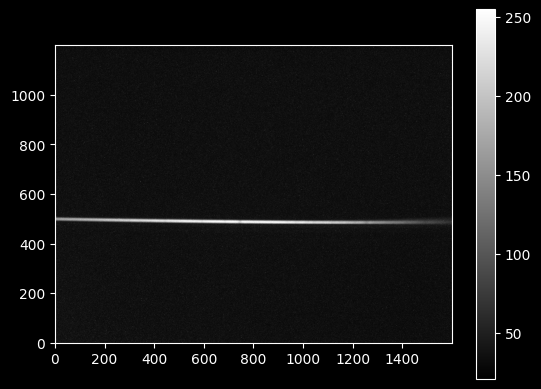

In [2]:
spectrum_filename = "aldebaran_3s_1.bmp"
image_array_2 = np.array(Image.open('deneb_3s_13.63g_1.bmp'))
plt.imshow(image_array_2, cmap='gray')
plt.colorbar();

In [3]:
image_data = Image.open(spectrum_filename)

Se define una variable que almacena el nombre del archivo de imagen (en este caso, un archivo BMP).

Ahora la imagen un objeto de tipo PIL.Image.Image, lo que significa que se puede manipular la imagen usando los métodos de PIL, como cambiar su formato, tamaño o convertirla en una matriz NumPy.

Finalmente se muestra la imagen en pantalla automáticamente.

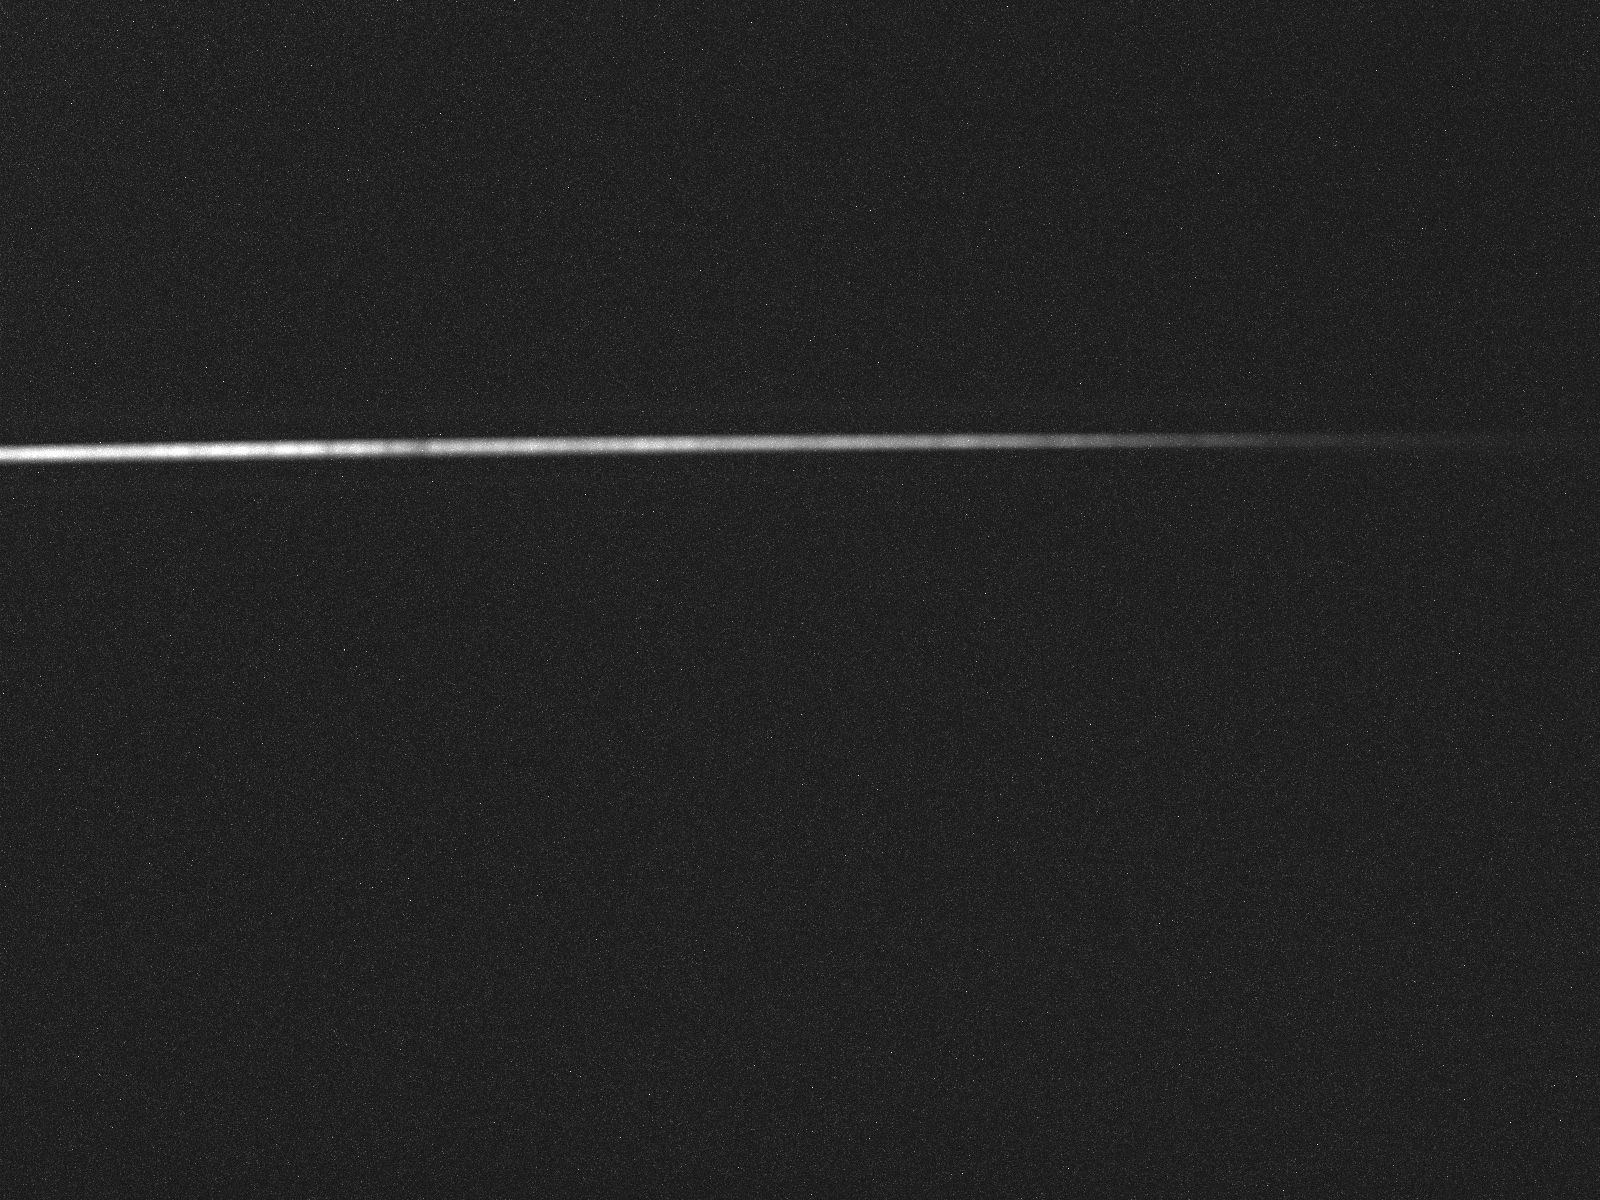

In [4]:
image_data

In [5]:
image_array = np.array(image_data)
image_array, image_array.shape

(array([[41, 43, 50, ..., 52, 28, 27],
        [33, 22, 48, ..., 37, 35, 26],
        [41, 64, 30, ..., 21, 30, 33],
        ...,
        [33, 28, 27, ..., 26, 33, 28],
        [35, 25, 23, ..., 23, 46, 46],
        [32, 35, 22, ..., 23, 40, 29]], dtype=uint8),
 (1200, 1600))

Aquí se convierte la imagen en un array NumPy. Este array representa la imagen en forma de una matriz de píxeles, que tendrá la forma (alto, ancho).


Muestra la imagen almacenada en image_data, cmap='gray' indica que la imagen debe visualizarse en escala de grises.

Se agrega una barra de colores al lado de la imagen, lo cual es útil cuando se trata de datos de intensidad o imágenes en escala de grises.

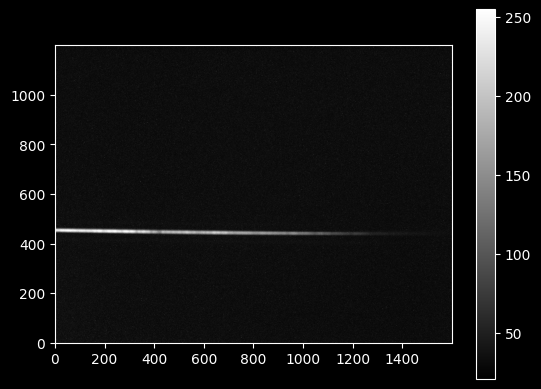

In [6]:
plt.imshow(image_data, cmap='gray')
plt.colorbar()

El objetivo es obtener un modelo f(x) que describa la posición vertical de la señal en la imagen, Comenzaremos asumiendo que la dispersión de la longitud de onda se produce en la dirección X y que la dirección Y es completamente espacial.

# Paso 2: Intentar encontrar la estructura central para trazar usando argmax.

Para obtener la traza, primero medimos el valor Y en cada valor X. Comenzaremos con el enfoque trivial de usar argmax:

In [7]:
yvals = np.argmax(image_data, axis=0)
xvals = np.arange(image_data.width)

Este código está tratando de encontrar la posición de la señal en función de la coordenada X, basándose en la imagen del espectro.

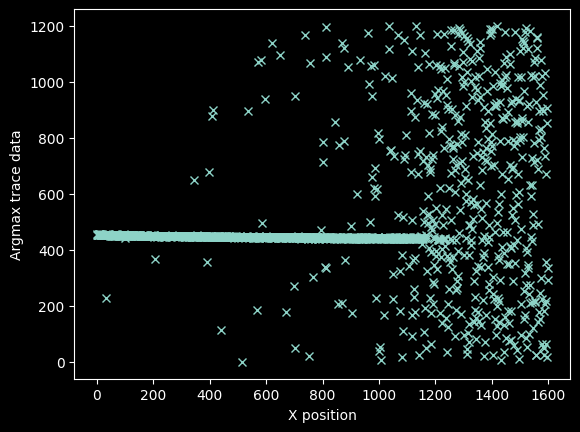

In [8]:
plt.plot(xvals, yvals, 'x')
plt.ylabel("Argmax trace data")
plt.xlabel("X position");

np.argmax(image_data, axis=0): Encuentra el índice del valor máximo a lo largo del eje vertical (eje 0) para cada columna de la matriz image_data.

Este código genera una "traza de máximos" de la imagen. Es decir, muestra la posición del píxel más brillante (o de mayor intensidad) en cada columna de la imagen, lo que podría ayudar a detectar contornos o formas dentro de la imagen.

In [9]:
bad_pixels = (yvals < 400) | (yvals > 500)

El objetivo del esta línea de código es descartar valores fuera de un umbral esperado, es decir fuera del trazado de la estrella.

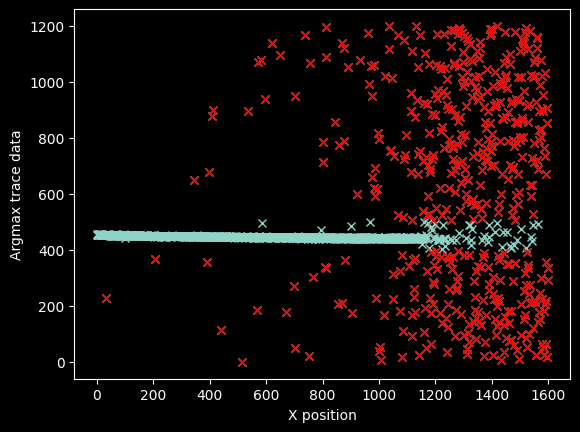

In [10]:
plt.plot(xvals, yvals, 'x')
plt.plot(xvals[bad_pixels], yvals[bad_pixels], 'rx')
plt.ylabel("Argmax trace data")
plt.xlabel("X position");

Este fragmento de código visualiza la traza de máximos en una imagen, resaltando en rojo los píxeles que están fuera del rango permitido.

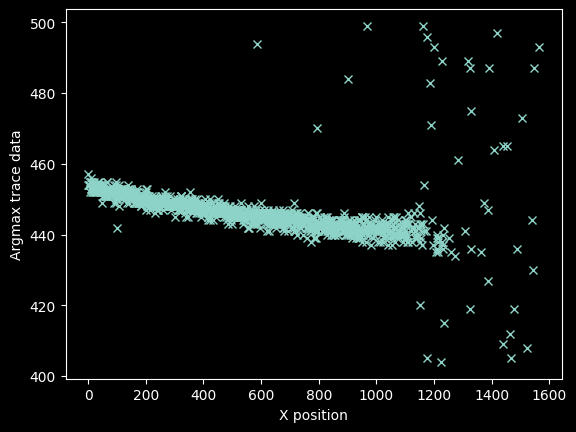

In [11]:
plt.plot(xvals[~bad_pixels], yvals[~bad_pixels], 'x')
plt.ylabel("Argmax trace data")
plt.xlabel("X position");

Esta parte visualiza solo los píxeles buenos (dentro del rango permitido) en la traza de máximos de la imagen, permitiendo ver solo los valores válidos, proporcionando una mejor interpretación de la traza de máximos.

In [12]:
bad_pixels = (yvals < 425) | (yvals > 460)

Esta línea define una nueva condición para detectar píxeles "malos" en la traza de máximos de la imagen, usando un umbral más estricto que la versión anterior (400-500), para enfocar aún más al trazado de la estrella.

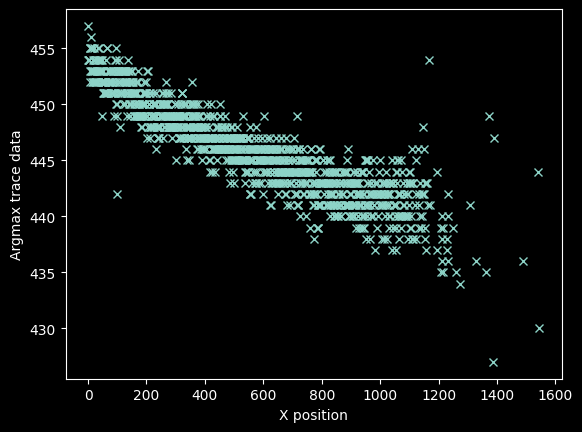

In [13]:
plt.plot(xvals[~bad_pixels], yvals[~bad_pixels], 'x')
plt.ylabel("Argmax trace data")
plt.xlabel("X position");

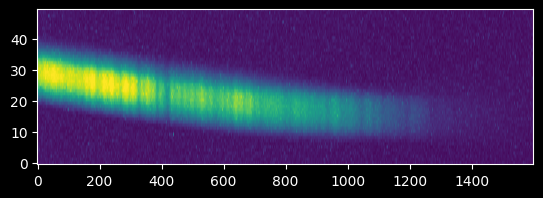

In [14]:
plt.imshow(image_array[425:475,:])
plt.gca().set_aspect(10)

plt.imshow(image_array[425:475,:])

Extrae una porción de la imagen desde la fila 425 hasta 475 (50 filas en total).

plt.gca().set_aspect(10)
Ajusta la relación de aspecto del gráfico. 10 significa que la altura de los píxeles se estira 10 veces más que su ancho, haciendo la imagen más alargada verticalmente. 

# Paso 2.b : Utiliza el análisis de momentos para extraer una estructura central a trazar.


Podemos usar momentos para obtener una estimación diferente, posiblemente mejor, de la ubicación del centro de la traza. La ventaja del análisis de momentos es que utilizamos todos los datos para estimar la posición vertical, no solo el valor más brillante, que es el que utilizamos anteriormente.

Tenga en cuenta que debemos restar el fondo para evitar un sesgo hacia el centro, por lo que utilizamos la mediana de toda la imagen como estimación del fondo.

(El momento de primer orden es la posición media ponderada por la intensidad,

$$m_1 = \frac{\sum_i x_if(x_i)}{\sum_if(x_i)}$$


Donde $x_i$ es la posición y $f(x_1)$ es la intensidad en esa posición. $f(x_i)$ debe ser cero en la región libre de señal para $m_1$ para devolver una estimación precisa de la ubicación del pico)

In [15]:
yaxis = np.repeat(np.arange(425, 475)[:,None],
                  image_array.shape[1], axis=1)
background = np.median(image_array)
# moment 1 is the data-weighted average of the Y-axis coordinates
weighted_yaxis_values = np.average(yaxis, axis=0,
                                   weights=image_array[425:475,:] - background)

Usamos un recorte alrededor de la línea trazada, por lo que los valores Y provienen de ese recorte.
El comando `repeat` se usa para extender los valores de posición del eje Y, que son 425, 426, ... 475,
A lo largo de la dirección X. La indexación con [:, None] agrega un eje "ficticio" a lo largo de la segunda dimensión (x).
Luego, `repeat` copia los valores del eje Y. La matriz resultante tiene la misma forma que nuestra matriz de pesos,
Que es image_array[425:475, :] menos la mediana.

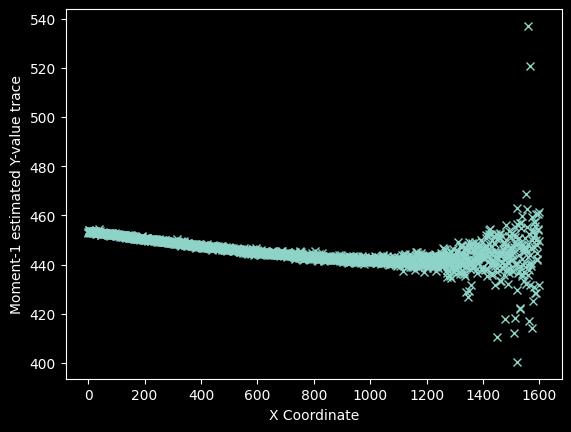

In [16]:
plt.plot(xvals, weighted_yaxis_values, 'x')
plt.xlabel("X Coordinate")
plt.ylabel("Moment-1 estimated Y-value trace");

Muestra cómo cambia la posición estimada de la línea trazada en la imagen a lo largo del eje X.

Se basa en la distribución de intensidad de la imagen, destacando la posición promedio de la señal en cada X.

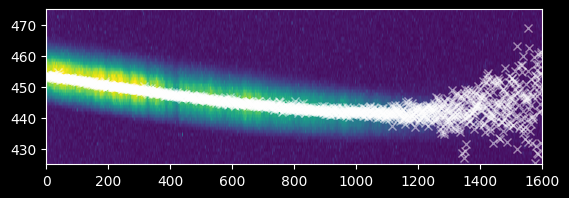

In [17]:
plt.imshow(image_array[425:475,:],
          extent=[0,image_array.shape[1],425,475])
plt.gca().set_aspect(10) # Estiramos la imagen 10x en la dirección y
plt.plot(xvals, weighted_yaxis_values, 'wx', alpha=0.5)
plt.axis((0,1600,425,475));

Se muestra una franja de la imagen (entre Y = 425 y Y = 475).

Los puntos blancos marcan la posición estimada de la señal en cada X.

La imagen está estirada en Y para facilitar la visualización.

También podemos comparar los enfoques argmax y ponderado. Coinciden bien en x < 1200, pero simplemente hay más puntos del enfoque ponderado en x > 1200.

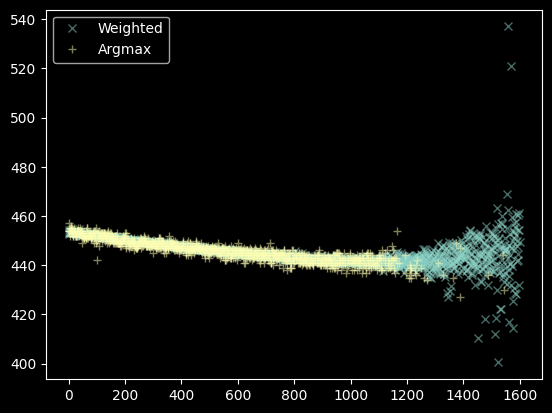

In [18]:
plt.plot(xvals, weighted_yaxis_values, 'x', label="Weighted", alpha=0.5)
plt.plot(xvals[~bad_pixels], yvals[~bad_pixels], '+', label="Argmax", alpha=0.5)
plt.legend(loc='best');

Compara el método Argmax (máximo absoluto) con el método Weighted (Momento-1).

Si los dos métodos coinciden bien, significa que la señal es fuerte y clara.

Si hay desviaciones, puede indicar ruido, variaciones en la intensidad, o problemas con el método de Argmax.

Ese es un buen conjunto de datos; usaremos los momentos en lugar del argmax. Sin embargo, aún quedan algunos datos por destacar.

In [19]:
bad_moments = (weighted_yaxis_values > 460) | (weighted_yaxis_values < 430)

Comparación visual de los valores Y obtenidos con dos métodos diferentes.

Se filtran valores anómalos para mejorar la precisión del análisis.

Muestra si hay desviaciones entre los dos métodos debido a ruido o diferencias en la intensidad.



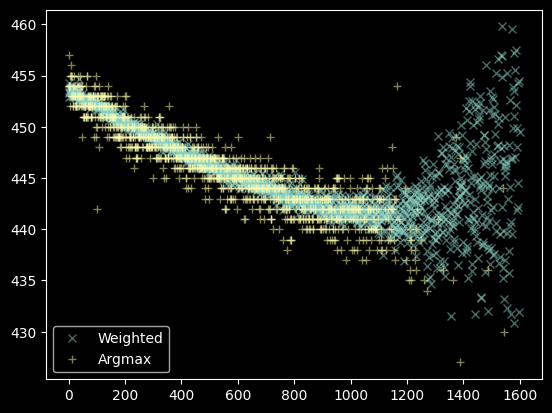

In [20]:
plt.plot(xvals[~bad_moments], weighted_yaxis_values[~bad_moments], 'x', label="Weighted", alpha=0.5)
plt.plot(xvals[~bad_pixels], yvals[~bad_pixels], '+', label="Argmax", alpha=0.5)
plt.legend(loc='best');

## Paso 3: Ajustar el perfil de la traza.

Queremos un modelo f(x) que dé el valor "y" del centroide en función de x.

In [21]:
from astropy.modeling.polynomial import Polynomial1D
from astropy.modeling.fitting import LinearLSQFitter

Estas dos importaciones permiten construir y ajustar modelos polinómicos a datos experimentales o simulados

In [22]:
polymodel = Polynomial1D(degree=2)
linfitter = LinearLSQFitter()
fitted_polymodel = linfitter(polymodel, xvals[~bad_moments], weighted_yaxis_values[~bad_moments])

Ajustamos un polinomio de segundo orden

In [23]:
fitted_polymodel

<Polynomial1D(2, c0=454.80138106, c1=-0.02381282, c2=0.00001121)>

$$f(x)=0.00001121x^2-0.02381282x+454.80138106$$

Este código ajusta un polinomio de segundo grado a un conjunto de datos filtrado, utilizando mínimos cuadrados, y luego grafica los datos originales junto con la curva ajustada.

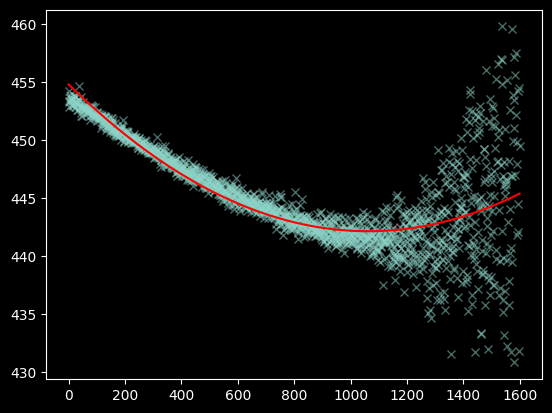

In [24]:
plt.plot(xvals[~bad_moments], weighted_yaxis_values[~bad_moments], 'x', alpha=0.5)
plt.plot(xvals, fitted_polymodel(xvals), color='r');

Graficamos y examinamos los residuos para inspeccionar visualmente si el ajuste es bueno:

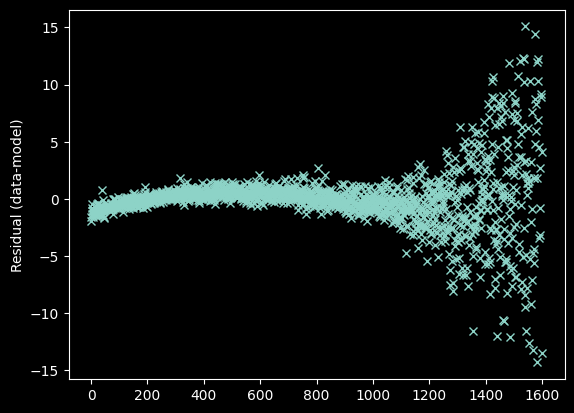

In [25]:
plt.plot(xvals[~bad_moments],
        weighted_yaxis_values[~bad_moments] - fitted_polymodel(xvals[~bad_moments]), 'x')
plt.ylabel("Residual (data-model)");

La curvatura que se observa a la izquierda indica un ajuste subóptimo. En concreto, la curvatura del residuo indica que necesitamos usar un modelo de orden superior; es decir, necesitamos más términos en el polinomio. Cambiamos grado=2 a grado=3.

In [26]:
polymodel = Polynomial1D(degree=3)
fitted_polymodel = linfitter(polymodel, xvals[~bad_moments], weighted_yaxis_values[~bad_moments])
fitted_polymodel

<Polynomial1D(3, c0=453.31622273, c1=-0.01256666, c2=-0.00000651, c3=0.00000001)>

$$f(x)=0.00000001x^3-0.00000651x^2-0.01256666x+453.31622273$$

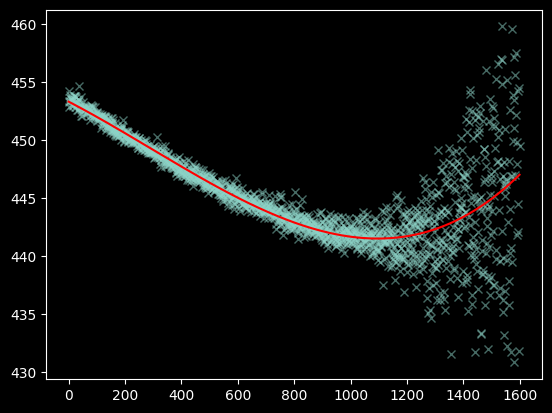

In [27]:
plt.plot(xvals[~bad_moments], weighted_yaxis_values[~bad_moments], 'x', alpha=0.5)
plt.plot(xvals, fitted_polymodel(xvals), color='r');

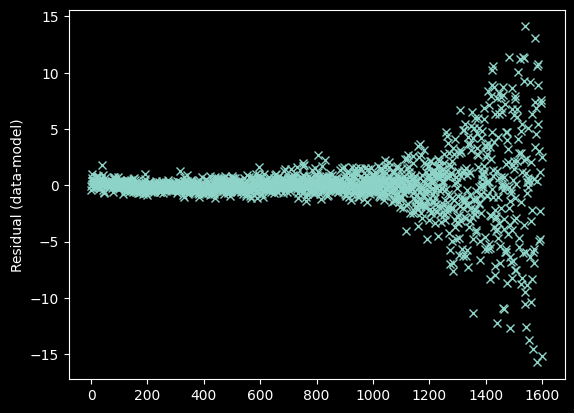

In [28]:
plt.plot(xvals[~bad_moments],
      weighted_yaxis_values[~bad_moments] - fitted_polymodel(xvals[~bad_moments]), 'x')
plt.ylabel("Residual (data-model)");

Podríamos descartar los datos a más de 1400 píxeles, ya que no hay una señal clara allí. Volveremos a esto...

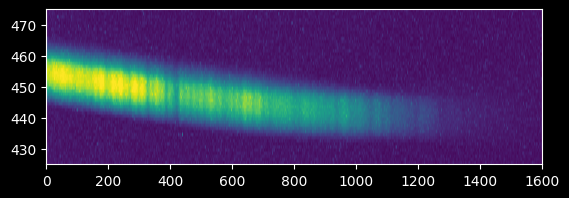

In [29]:
plt.imshow(image_array[425:475,:],
          extent=[0,image_array.shape[1],425,475])
plt.gca().set_aspect(10);

Nuevamente, debemos verificar el rastro superponiendo el gráfico sobre los datos originales:

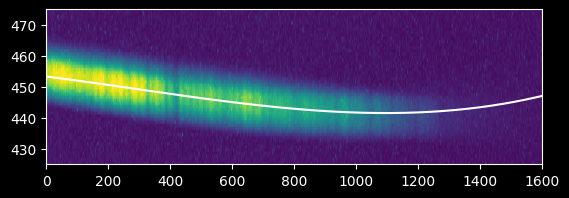

In [30]:
plt.imshow(image_array[425:475,:], extent=[0,image_array.shape[1],425,475])
plt.gca().set_aspect(10)
plt.plot(xvals, fitted_polymodel(xvals), 'w')
plt.axis((0,1600,425,475));

Al observar la curva hacia arriba en el modelo hacia la derecha (que no observamos en los datos), se sugiere que deberíamos volver a ajustar sin incluir en absoluto los datos x>1200:

In [31]:
polymodel = Polynomial1D(degree=3)
fitted_polymodel = linfitter(polymodel, xvals[(~bad_moments) & (xvals < 1200)],
                             weighted_yaxis_values[(~bad_moments) & (xvals < 1200)])
fitted_polymodel

<Polynomial1D(3, c0=453.63074008, c1=-0.01596396, c2=0.00000083, c3=0.)>

$$f(x)=0.x^3+0.00000083x^2-0.01596396x+453.63074008$$

Ahora tenemos un ajuste satisfactorio:

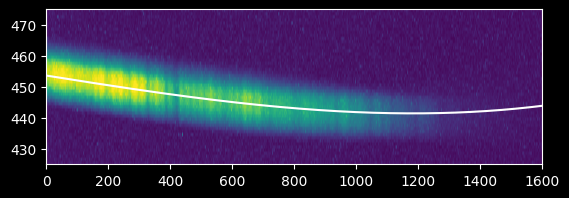

In [32]:
plt.imshow(image_array[425:475,:], extent=[0,image_array.shape[1],425,475])
plt.gca().set_aspect(10)
plt.plot(xvals, fitted_polymodel(xvals), 'w')
plt.axis((0,1600,425,475));

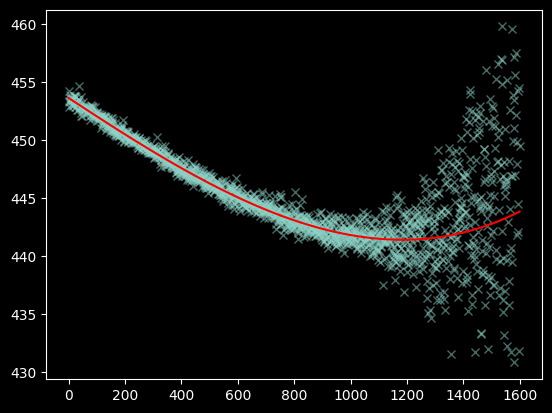

In [33]:
plt.plot(xvals[~bad_moments], weighted_yaxis_values[~bad_moments], 'x', alpha=0.5)
plt.plot(xvals, fitted_polymodel(xvals), color='r');

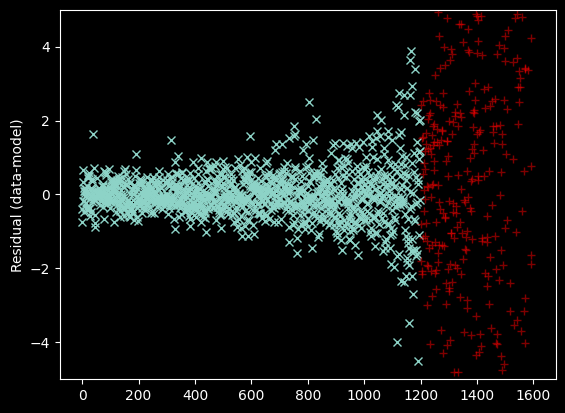

In [34]:
plt.plot(xvals[~bad_moments & (xvals < 1200)],
        weighted_yaxis_values[~bad_moments & (xvals < 1200)] - fitted_polymodel(xvals[~bad_moments & (xvals < 1200)]), 'x')
plt.plot(xvals[~bad_moments & (xvals > 1200)],
        weighted_yaxis_values[~bad_moments & (xvals > 1200)] - fitted_polymodel(xvals[~bad_moments & (xvals > 1200)]), 'r+', alpha=0.5)
plt.ylim(-5, 5)
plt.ylabel("Residual (data-model)");

## Paso 4 : Crear un perfil de la traza.


Ahora podemos extraer los datos a lo largo de esa traza.

Queremos crear un perfil de la traza para ver cuántos píxeles a cada lado de la línea debemos incluir.

Este fragmento de código usa matplotlib para visualizar una porción de una imagen y superponer una región sombreada alrededor de un modelo polinomial ajustado.

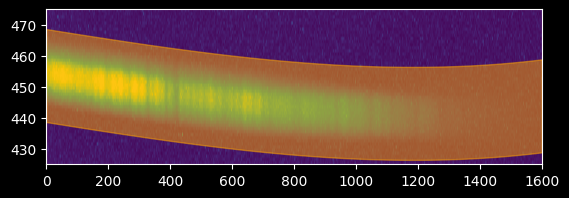

In [35]:
plt.imshow(image_array[425:475,:], extent=[0,image_array.shape[1],425,475])
plt.gca().set_aspect(10)
plt.fill_between(xvals, fitted_polymodel(xvals)-15,
                fitted_polymodel(xvals)+15,
                color='orange', alpha=0.5)
plt.axis((0,1600,425,475));

Ese último paso merece una explicación:

cutouts = np.array([image_array[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii]
for yval, ii in zip(trace_center, xvals)])
[... for yval, ii in zip(trace_center, xvals)] toma cada valor de traza y y cada valor de traza x y los comprime, por lo que cada iteración del bucle for tiene un par x, y.
image_array[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii] toma un solo píxel en la dirección x (la segunda dimensión, ii) y un rango de píxeles en la dirección y, es decir, y+/-n.
Estos se unen en un bucle, por lo que tenemos una región de píxeles y+/-n para cada uno. x píxeles
Luego los convertimos en una matriz.
Podemos ver el resultado visualmente:

In [36]:
npixels_to_cut = 15
trace_center = fitted_polymodel(xvals)
cutouts = np.array([image_array[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii]
                    for yval, ii in zip(trace_center, xvals)])
cutouts.shape

(1600, 30)

Este fragmento de código extrae pequeñas porciones de la imagen a lo largo de una curva ajustada (definida por fitted_polymodel(xvals)). Extrae pequeñas secciones verticales de la imagen a lo largo de la curva fitted_polymodel(xvals). Este código muestra cómo se transforma una franja de la imagen original en una versión ajustada basada en cutouts. 

🔹 Primer gráfico: Porción original de la imagen.

🔹 Segundo gráfico: Porción procesada y alineada con la curva del modelo polinomial.

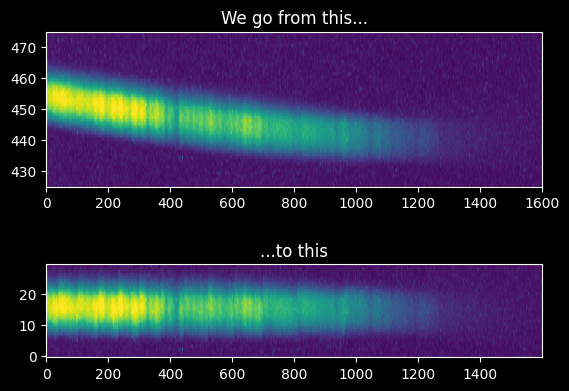

In [37]:
ax1 = plt.subplot(2,1,1)
ax1.imshow(image_array[425:475,:], extent=[0,image_array.shape[1],425,475])
ax1.set_aspect(10)
ax1.set_title("We go from this...")
ax2 = plt.subplot(2,1,2)
ax2.imshow(cutouts.T)
ax2.set_title("...to this")
ax2.set_aspect(10)

Luego, promediamos a lo largo de la dirección X para obtener el perfil de traza:

Este código calcula y visualiza el perfil promedio de la traza extraída de la imagen.

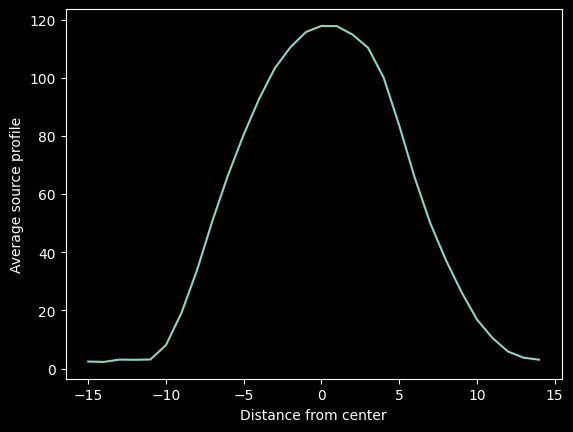

In [38]:
mean_trace_profile = (cutouts - background).mean(axis=0)
trace_profile_xaxis = np.arange(-npixels_to_cut, npixels_to_cut)
plt.plot(trace_profile_xaxis, mean_trace_profile)
plt.xlabel("Distance from center")
plt.ylabel("Average source profile");

Queremos ajustar ese perfil con un gaussiano para uso futuro, por lo que importamos el perfil del modelo gaussiano y el ajustador no lineal y ejecutamos un ajuste:

In [39]:
from astropy.modeling.models import Gaussian1D
from astropy.modeling.fitting import LevMarLSQFitter
lmfitter = LevMarLSQFitter()
guess = Gaussian1D(amplitude=mean_trace_profile.max(), mean=0, stddev=5)
fitted_trace_profile = lmfitter(model=guess, x=trace_profile_xaxis, y=mean_trace_profile)
model_trace_profile = fitted_trace_profile(trace_profile_xaxis)
fitted_trace_profile

ModuleNotFoundError: No module named 'scipy'

NameError: name 'model_trace_profile' is not defined

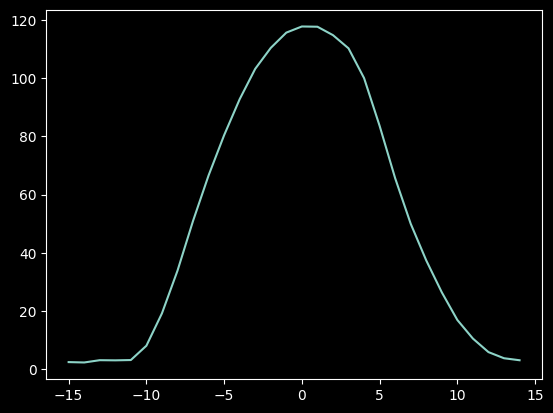

In [ ]:
plt.plot(trace_profile_xaxis, mean_trace_profile, label='data')
plt.plot(trace_profile_xaxis, model_trace_profile, label='model')
plt.legend(loc='best')
plt.xlabel("Distance from center")
plt.ylabel("Average source profile");

Se pueden utilizar razonablemente tanto el perfil de seguimiento empírico mean_trace_profile como el model_trace_profile modelado; este último es más conveniente para serializar (es decir, escribir en disco o en papel).

# Paso 5 : Sacar espectro de la traza


Podemos obtener nuestro espectro promediando directamente los píxeles a lo largo de la traza:

In [ ]:
average_spectrum = (cutouts - background).mean(axis=1)
plt.plot(average_spectrum);

NameError: name 'cutouts' is not defined

O podemos obtener nuestro espectro tomando el promedio ponderado por trazas:

In [ ]:
trace_avg_spectrum = np.array([np.average(
    image_array[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii] - background,
    weights=mean_trace_profile)
                               for yval, ii in zip(trace_center, xvals)])

NameError: name 'np' is not defined

También podemos hacer esto con los pesos gaussianos:

In [ ]:
gaussian_trace_avg_spectrum = np.array([np.average(
    image_array[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii] - background,
    weights=model_trace_profile)
                               for yval, ii in zip(trace_center, xvals)])

NameError: name 'model_trace_profile' is not defined

NameError: name 'gaussian_trace_avg_spectrum' is not defined

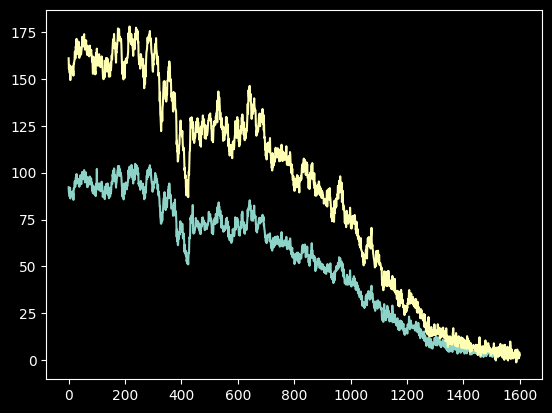

In [ ]:
plt.plot(average_spectrum, label="Direct Average")
plt.plot(trace_avg_spectrum, label='Trace-weighted average')
plt.plot(gaussian_trace_avg_spectrum, label='Gaussian-model-Trace-weighted average', alpha=0.5, linewidth=0.5, color='r')
plt.legend(loc='best');

En general, el promedio ponderado por trazas tendrá una relación señal-ruido más alta, como se observa aquí (aunque no hemos medido el ruido, este es aproximadamente constante en toda la imagen).

Observe que el modelo gaussiano y la traza directa arrojan resultados casi idénticos.

# Paso 6: Repita para otra estrella

En este último paso, repasamos todos los pasos anteriores nuevamente para otra estrella (Deneb), pero con menos explicación.

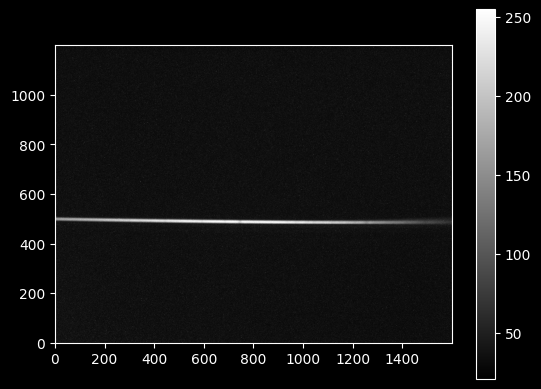

In [ ]:
image_array_2 = np.array(Image.open('deneb_3s_13.63g_1.bmp'))
plt.imshow(image_array_2, cmap='gray')
plt.colorbar();

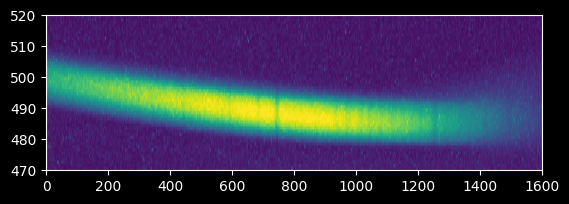

In [ ]:
plt.imshow(image_array_2[470:520,:], extent=[0,1600,470,520])
plt.gca().set_aspect(10)

In [ ]:
yaxis2 = np.repeat(np.arange(470, 520)[:,None], image_array_2.shape[1], axis=1)
weighted_yaxis_values2 = np.average(yaxis2, axis=0, weights=image_array_2[470:520,:] - np.median(image_array_2))
polymodel2 = Polynomial1D(degree=3)
fitted_polymodel2 = linfitter(polymodel2, xvals, weighted_yaxis_values2)
trace_center2 = fitted_polymodel2(xvals)

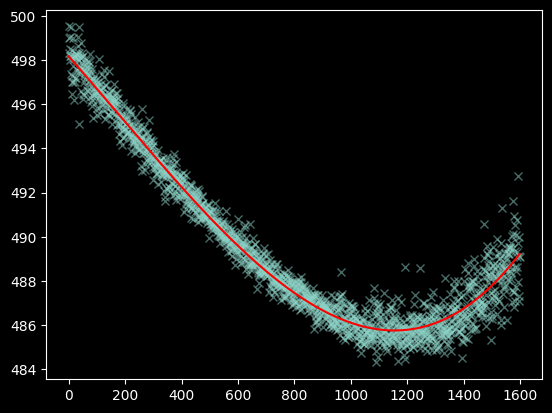

In [ ]:
plt.plot(xvals, weighted_yaxis_values2, 'x', alpha=0.5)
plt.plot(xvals, trace_center2, color='r');

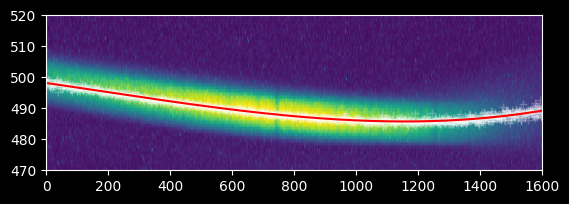

In [ ]:
plt.imshow(image_array_2[470:520,:], extent=[0,1600,470,520])
plt.plot(xvals, weighted_yaxis_values2, 'w+', alpha=0.25)
plt.plot(xvals, trace_center2, color='r')
plt.gca().set_aspect(10)

In [ ]:
spectrum2 = np.array([np.average(image_array_2[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii] - np.median(image_array_2),
                                weights=mean_trace_profile)
                     for yval, ii in zip(trace_center2, xvals)])

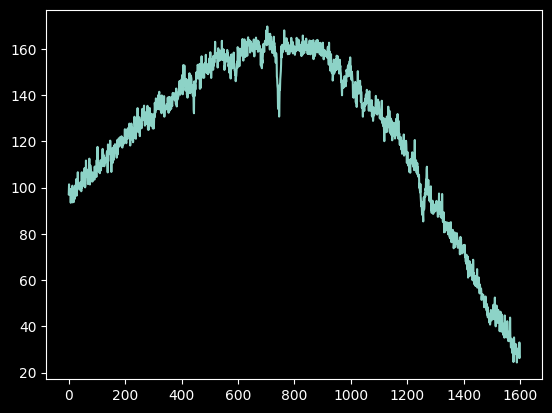

In [ ]:
plt.plot(spectrum2);

En el próximo tutorial, Reducción de datos espectroscópicos 2, trabajaremos en la calibración de la longitud de onda.

In [ ]:
image_array_3 = np.array(Image.open('vega_2.bmp').convert("L"))
plt.imshow(image_array_3, cmap='gray')
plt.colorbar();

FileNotFoundError: [Errno 2] No such file or directory: '/home/cesarm/Escritorio/Astropy/Astronomia-observacional/vega_2.bmp'

In [ ]:
plt.imshow(image_array_3[200:400,:], extent=[0,1600,470,520])
plt.gca().set_aspect(10)



NameError: name 'image_array_3' is not defined

In [ ]:
xvals = np.arange(image_array_3.shape[1])
yaxis3 = np.repeat(np.arange(200, 400)[:,None], image_array_3.shape[1], axis=1)
weighted_yaxis_values3 = np.average(yaxis3, axis=0, weights=image_array_3[200:400,:] - np.median(image_array_3))
polymodel3 = Polynomial1D(degree=3)
fitted_polymodel3 = linfitter(polymodel3, xvals, weighted_yaxis_values3)
trace_center3 = fitted_polymodel3(xvals)




NameError: name 'image_array_3' is not defined

In [ ]:
print(yaxis3.shape)
print((image_array_3[200:400, :] - np.median(image_array_3)).shape)


NameError: name 'yaxis3' is not defined